# Assignment 3
### Due 9/21. Do four of five.

1. 
- Open the NHANES (or Ames prices or college completion datasets, if you prefer)
- Find two categorical variables of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis like we did with police use of force, but always be aware of how dirty the data are)
- Compute a contingency table for your categorical $X$ and $Y$
- Discuss any interesting patterns (or lack of one) that you observe

In [1]:
# importing all the necessary packages 
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# going to open the college complettion data set 
df = pd.read_csv("./data/college_completion.csv")
df.head()

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


In [19]:
# the categorical variables of choice are 
# hbcu 
# control -  whether its public, private non for profit or private for profit
# investigating missing values 
df['level_na'] = df['level'].isna()
print(df['level_na'].value_counts())
print("----------------------")
df['control_na'] = df['control'].isna()
print(df['control_na'].value_counts())

level_na
False    3798
Name: count, dtype: int64
----------------------
control_na
False    3798
Name: count, dtype: int64


In [20]:
# making the contingency table 
pd.crosstab(df['level'], df['control'], normalize='columns') # Normalized to proportions

control,Private for-profit,Private not-for-profit,Public
level,,,
2-year,0.46875,0.054487,0.594352
4-year,0.53125,0.945513,0.405648


The most interesting pattern that I notice is that Private for-profit and Public colleges and universities have around 50% split between 2-year and 4-year schooling. On the other hand, Private not-for-profit have an overwhelmingly uneven distribution with only 5% of their schools being 2-year and 95% are 4 year schools. 

2. 
- Open the NHANES dataset
- Find a categorical and numeric variable of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis, but always be aware of them)
- Make descriptive tables and grouped kernel density plots to represent the variation in your numeric $Y$ conditional on your categorical $X$
- Discuss any interesting patterns (or lack of one) that you observe

In [22]:
nhanes = pd.read_csv("./data/nhanes_data_17_18.csv")
nhanes.head(5)

/var/folders/gr/s43l36xd55s6nsrb_jk9hkdw0000gn/T/ipykernel_47301/2332803463.py:1: DtypeWarning: Columns (142) have mixed types. Specify dtype option on import or set low_memory=False.
  nhanes = pd.read_csv("./data/nhanes_data_17_18.csv")


,SEQN,GeneralHealthCondition,EverBreastfedOrFedBreastmilk,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays,TypeOfMilkFirstFedWholeMilk,TypeOfMilkFirstFed2Milk,...,DaysSmokedCigsDuringPast30Days,AvgCigarettesdayDuringPast30Days,TriedToQuitSmoking,TimesStoppedSmokingCigarettes,HowLongWereYouAbleToStopSmoking,UnitOfMeasureDayweekmonthyear_2_SMQ,CurrentSelfreportedHeightInches,CurrentSelfreportedWeightPounds,TriedToLoseWeightInPastYear,TimesLost10LbsOrMoreToLoseWeight
0,93703.0,NaN,1.0,273.0,1.0,365.0,152.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,NaN,1.0,60.0,3.0,365.0,126.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,63.0,165.0,0.0,11 times or more
3,93706.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,145.0,0.0,Never
4,93707.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# categorical and numeric variable 
# categorical choice: 'GeneralHealthCondition"
# numeric choice: AnnualHouseholdIncome
# going to analyze their missing values 
nhanes['HC_NA'] = nhanes['GeneralHealthCondition'].isna()
print(nhanes['HC_NA'].value_counts())
print("--------------------------")
nhanes['Income_NA'] = nhanes['AnnualHouseholdIncome'].isna()
print(nhanes['Income_NA'].value_counts())

HC_NA
False    5964
True     2402
Name: count, dtype: int64
--------------------------
Income_NA
False    7237
True     1129
Name: count, dtype: int64


In [ ]:
# interesting amount of missings so going to try to look at the proportions of missing
pd.crosstab( nhanes['type_resistance'],nhanes['injury_na'],normalize='index')
# COME BACK TO THIS AND FINISH

In [30]:
# making the descriptive table
nhanes.loc[:,['GeneralHealthCondition', 'AnnualHouseholdIncome']].groupby('GeneralHealthCondition').describe()

AnnualHouseholdIncome                              \
                                       count          mean           std   
GeneralHealthCondition                                                     
Excellent                              546.0  60762.820513  33746.465265   
Fair or                                989.0  42188.068756  30452.732990   
Good                                  2143.0  52474.101727  31306.042652   
Poor?                                  136.0  33944.852941  27493.815654   
Very good                             1352.0  63579.142012  32224.129874   

                                                                      
                           min      25%      50%       75%       max  
GeneralHealthCondition                                                
Excellent               2000.0  30000.0  60000.0  100000.0  100000.0  
Fair or                 2000.0  17500.0  30000.0   60000.0  100000.0  
Good                    2000.0  30000.0  50000.0   87500.0  100000.0  
Poor?                   2000.0  17500.0  30000.0   40000.0  100000.0  
Very good               2000.0  30000.0  60000.0  100000.0  100000.0

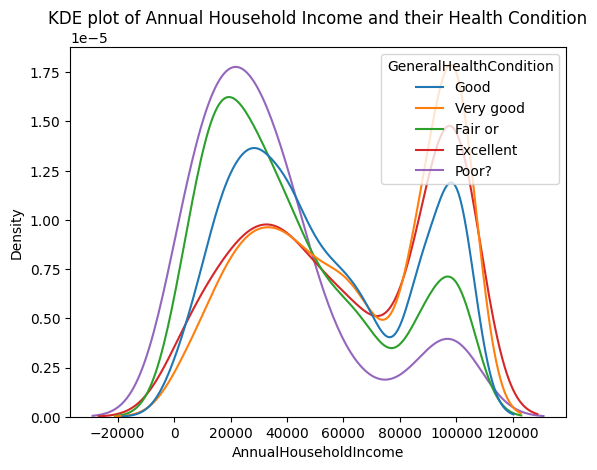

In [33]:
# making the KDE plot
sns.kdeplot(data=nhanes, x='AnnualHouseholdIncome', hue='GeneralHealthCondition', common_norm=False ).set(title='KDE plot of Annual Household Income and their Health Condition')
plt.show()

There are a great number of missings for the Annual Household Income and General Health Conditon. 

3. 
We showed that the mean and median could be discovered by minimizing various kinds of loss functions; this is what machine learning is. To make a prediction $\hat{y}(z)$ of $Y$ when $X=z$, minimize the mean squared error:
$$
MSE(\hat{y}(z)) = \dfrac{1}{N} \sum_{i=1}^N \left\lbrace y_i - \hat{y}(z) \right\rbrace^2 \frac{1}{h}k\left(\frac{z-x_i}{h}\right)
$$
Show that the solution to this problem is the LCLS/Naradaya-Watson estimator.

4. 
- Write a class or set of functions that implement the LCLS/Naradaya-Watson estimator, using the Silverman plug-in estimate for the conditioning variable $X$ as the bandwidth.
- From one of the course data sets, find two numeric variables of interest, analyze their relationship with the the LCLS/Naradaya-Watson estimator, and discuss your results.

5. 
- In any of the available data sets, investigate the relationships between pairs of variables $(X,Y)$ with a scatterplot and CEF (for example, price on area)
- Is this relationship plausibly causal, or are there missing variables that might explain at least part of the relationship between your variables? These can be "conceptual" rather than "practical"; for example, 'talent' or 'grit' probably explain education outcomes, but are almost impossible to measure. We are asking whether there are hypothetical **threats to causal identification** of the effect of $X$ on $Y$.
- Explain how, regardless of the threat to causal identification, you can still use your model to predict $Y$ given $X$, as long as you don't intervene in the system to control the outcome